# LAB DAY 19: Dataset-driven GraphRAG cho Electric Vehicle Corpus

Notebook này làm lại bài lab bằng dataset thật trong thư mục `dataset/` gồm 70 file text về thị trường xe điện, charging infrastructure, sentiment, chính sách và các công ty EV. Script có hỗ trợ Gemini API tùy chọn thông qua file `.env`.

## 1. Mục tiêu và nghiên cứu

**Entity Extraction:** từ mỗi document, hệ thống nhận diện entity như `Electric Vehicle`, `Charging Infrastructure`, `Nikola`, `HYLA`, `California`, `Consumer Sentiment`, `Battery Capacity`.

**Graph Construction:** các entity và relation được đưa vào NetworkX MultiDiGraph. Deduplication giúp tránh tách node khi cùng một khái niệm xuất hiện dưới nhiều cách viết.

**Query Answering:** Flat RAG retrieve văn bản gần câu hỏi nhất bằng TF-IDF; GraphRAG detect entity rồi duyệt graph 2-hop để gom evidence có cấu trúc. Nếu bật `USE_GEMINI=true`, Gemini sẽ synthesize câu trả lời cuối từ evidence GraphRAG.

## 2. Cấu hình Gemini tùy chọn

Tạo/cập nhật file `.env`:

```text
GEMINI_API_KEY=PASTE_YOUR_GEMINI_API_KEY_HERE
GEMINI_MODEL=gemini-1.5-flash
USE_GEMINI=false
```

Đổi `USE_GEMINI=true` sau khi đã add API key. Cài package nếu cần: `python -m pip install google-generativeai`. Không push key thật lên GitHub.

## 3. Code chính

Cell dưới đây định nghĩa toàn bộ pipeline: load dataset, extract triples, build graph, Flat RAG, GraphRAG, Gemini synthesis tùy chọn và benchmark.

In [1]:
"""
LAB DAY 19: Dataset-driven GraphRAG cho Electric Vehicle Corpus

Cach chay:
    python day19_graphrag_lab.py

Input:
    dataset/doc_1.txt ... dataset/doc_70.txt

Output:
    graphrag_knowledge_graph.png
    benchmark_results.csv
"""

from __future__ import annotations

import os
import re
import time
from collections import Counter, deque
from dataclasses import dataclass
from pathlib import Path

import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import networkx as nx
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

try:
    OUTPUT_DIR = Path(__file__).resolve().parent
except NameError:
    OUTPUT_DIR = Path.cwd()

DATASET_DIR = OUTPUT_DIR / "dataset"
GRAPH_IMAGE = OUTPUT_DIR / "graphrag_knowledge_graph.png"
BENCHMARK_CSV = OUTPUT_DIR / "benchmark_results.csv"
ENV_PATH = OUTPUT_DIR / ".env"


def load_env(env_path: Path = ENV_PATH) -> None:
    """Load simple KEY=VALUE pairs from .env without requiring python-dotenv."""
    if not env_path.exists():
        return
    for line in env_path.read_text(encoding="utf-8").splitlines():
        line = line.strip()
        if not line or line.startswith("#") or "=" not in line:
            continue
        key, value = line.split("=", 1)
        key = key.strip()
        value = value.strip().strip('"').strip("'")
        os.environ.setdefault(key, value)


load_env()
USE_GEMINI = os.getenv("USE_GEMINI", "false").lower() in {"1", "true", "yes", "y"}
GEMINI_API_KEY = os.getenv("GEMINI_API_KEY", "").strip()
GEMINI_MODEL = os.getenv("GEMINI_MODEL", "gemini-1.5-flash").strip()


@dataclass(frozen=True)
class Triple:
    subject: str
    relation: str
    object: str


DOMAIN_ENTITIES = [
    "Electric Vehicle", "EV", "EV adoption", "EV sales", "EV market", "Electric Mobility",
    "Charging Infrastructure", "Public Charging", "Workplace Charging", "Home Charging",
    "Battery", "Battery Capacity", "Driving Range", "Fast Charging", "Green Charging",
    "Hydrogen Fuel Cell", "Hydrogen Refueling", "Zero-Emission Vehicle", "ZEV Regulation",
    "Inflation Reduction Act", "California", "United States", "U.S.", "Europe", "China",
    "Tesla", "Nikola", "NVIDIA", "Polestar", "VinFast", "ZEEKR", "Mercedes-Benz",
    "REE Automotive", "McKinsey", "ICCT", "IEA", "Deloitte", "BloombergNEF", "Cox Automotive",
    "PwC", "Goldman Sachs", "Pew Research Center", "EPA", "EIA", "AFDC",
    "HYLA", "Voltera", "Iveco", "Fortescue Future Industries", "Walmart", "Linde",
    "Amazon", "AWS", "Google", "Microsoft", "BYD", "Ford", "General Motors", "Rivian", "Lucid",
    "Consumer Sentiment", "Investor Sentiment", "Dealer Sentiment", "Market Sentiment",
    "Policy Support", "Consumer Incentives", "Federal Incentives", "Public Chargers",
]

BENCHMARK_QUESTIONS = [
    {
        "question": "What factors support electric vehicle market growth in U.S. cities?",
        "expected": "EV growth is supported by ZEV regulations, model availability, incentives, and public/workplace charging.",
        "entities": ["Electric Vehicle", "ZEV Regulation", "Consumer Incentives", "Public Charging"],
    },
    {
        "question": "How does charging infrastructure affect EV adoption?",
        "expected": "Charging infrastructure improves consumer confidence and supports EV adoption; insufficient chargers slow adoption.",
        "entities": ["Charging Infrastructure", "EV adoption", "Consumer Sentiment"],
    },
    {
        "question": "What concerns do consumers have about EV charging?",
        "expected": "Consumers worry about public charger availability, charging speed, battery capacity, and driving range.",
        "entities": ["Public Charging", "Fast Charging", "Battery Capacity", "Driving Range"],
    },
    {
        "question": "What business areas did Nikola focus on in its Q1 2023 report?",
        "expected": "Nikola focused on North America, hydrogen fuel cell trucks, HYLA hydrogen refueling, and autonomous technologies.",
        "entities": ["Nikola", "Hydrogen Fuel Cell", "HYLA", "Hydrogen Refueling"],
    },
    {
        "question": "How is HYLA related to Nikola and hydrogen refueling?",
        "expected": "HYLA is Nikola's hydrogen refueling business/ecosystem for zero-emission trucks.",
        "entities": ["HYLA", "Nikola", "Hydrogen Refueling"],
    },
    {
        "question": "Which policy context is connected to zero-emission trucks in California?",
        "expected": "California CARB/Advanced Clean Fleets requires zero-emission drayage trucks over time.",
        "entities": ["California", "Zero-Emission Vehicle", "Policy Support"],
    },
    {
        "question": "What does McKinsey say consumers want from EV charging?",
        "expected": "Consumers want convenient charging, enough public chargers, fast charging, range, and green charging options.",
        "entities": ["McKinsey", "Public Charging", "Fast Charging", "Green Charging"],
    },
    {
        "question": "How are battery capacity and driving range related to hesitant EV buyers?",
        "expected": "Some hesitant EV buyers wait for better battery capacity and longer driving range before purchasing.",
        "entities": ["Battery Capacity", "Driving Range", "Consumer Sentiment"],
    },
    {
        "question": "What role do consumer incentives play in EV market development?",
        "expected": "Consumer incentives help market development and are linked to higher EV uptake in top metropolitan areas.",
        "entities": ["Consumer Incentives", "EV market", "EV adoption"],
    },
    {
        "question": "Which organizations appear as sources for EV market and sentiment analysis?",
        "expected": "Sources include ICCT, McKinsey, Deloitte, BloombergNEF, Cox Automotive, IEA, EPA, EIA, and PwC.",
        "entities": ["ICCT", "McKinsey", "Deloitte", "BloombergNEF", "PwC"],
    },
    {
        "question": "What is the relationship between public chargers and high EV uptake areas?",
        "expected": "High uptake areas have much greater public charger availability per million population.",
        "entities": ["Public Chargers", "EV adoption", "Charging Infrastructure"],
    },
    {
        "question": "How does home charging compare with public charging in consumer behavior?",
        "expected": "Many charging sessions happen at home, but public charging remains critical for adoption.",
        "entities": ["Home Charging", "Public Charging", "EV adoption"],
    },
    {
        "question": "What is the connection between EV sales growth and market sentiment?",
        "expected": "EV sales growth has slowed in some markets, affecting market/dealer/investor sentiment.",
        "entities": ["EV sales", "Market Sentiment", "Dealer Sentiment"],
    },
    {
        "question": "Which companies are discussed in the financial performance documents?",
        "expected": "Financial performance documents discuss NVIDIA, Polestar, VinFast, ZEEKR, Mercedes-Benz, REE Automotive, and Nikola.",
        "entities": ["NVIDIA", "Polestar", "VinFast", "ZEEKR", "Nikola"],
    },
    {
        "question": "How is China connected to the electric vehicle market in the dataset?",
        "expected": "China appears in documents about EV industry internationalization, innovation, batteries, and market dominance.",
        "entities": ["China", "EV market", "Battery"],
    },
    {
        "question": "What does the dataset say about U.S. EV investments?",
        "expected": "The dataset includes a document about U.S. EV investments growing to $188 billion.",
        "entities": ["United States", "EV market", "Investor Sentiment"],
    },
    {
        "question": "Which stakeholders need to act to improve EV charging infrastructure?",
        "expected": "Industry stakeholders, OEMs, startups, utilities and policy makers need to invest in charging infrastructure.",
        "entities": ["Charging Infrastructure", "Policy Support", "Consumer Sentiment"],
    },
    {
        "question": "How do policy supports relate to EV adoption?",
        "expected": "Strong state, city, utility, and ZEV policy supports are associated with higher EV adoption.",
        "entities": ["Policy Support", "ZEV Regulation", "EV adoption"],
    },
    {
        "question": "How is green charging related to consumer preferences?",
        "expected": "Many consumers consider renewable or green charging important, although they remain price conscious.",
        "entities": ["Green Charging", "Consumer Sentiment"],
    },
    {
        "question": "Why can GraphRAG help with this EV dataset compared with Flat RAG?",
        "expected": "GraphRAG connects entities like EV adoption, charging infrastructure, policy support, consumers, and companies across documents.",
        "entities": ["GraphRAG", "EV adoption", "Charging Infrastructure", "Policy Support"],
    },
]


def read_text(path: Path) -> str:
    for enc in ("utf-8", "utf-8-sig", "cp1252", "latin-1"):
        try:
            return path.read_text(encoding=enc)
        except UnicodeDecodeError:
            continue
    return path.read_text(encoding="utf-8", errors="replace")


def parse_document(path: Path) -> dict:
    raw = read_text(path)
    def match_field(name: str) -> str:
        m = re.search(rf"^{name}:\s*(.*)$", raw, re.MULTILINE)
        return m.group(1).strip() if m else ""

    content = raw.split("Full Content:", 1)[1].strip() if "Full Content:" in raw else raw
    return {
        "id": path.stem,
        "path": str(path.relative_to(OUTPUT_DIR)),
        "query": match_field("Query"),
        "title": match_field("Title") or path.stem,
        "link": match_field("Link"),
        "snippet": match_field("Snippet"),
        "text": content,
        "raw": raw,
    }


def load_dataset(dataset_dir: Path = DATASET_DIR) -> list[dict]:
    files = sorted(dataset_dir.glob("doc_*.txt"), key=lambda p: int(re.search(r"\d+", p.stem).group()))
    if not files:
        raise FileNotFoundError(f"No dataset files found in {dataset_dir}")
    return [parse_document(path) for path in files]


def canonical_entity(entity: str) -> str:
    entity = re.sub(r"\s+", " ", entity.strip(" .,:;()[]{}\n\t"))
    aliases = {
        "electric vehicles": "Electric Vehicle",
        "electric vehicle": "Electric Vehicle",
        "evs": "EV",
        "ev": "EV",
        "u.s.": "United States",
        "us": "United States",
        "usa": "United States",
        "charging infrastructure": "Charging Infrastructure",
        "public chargers": "Public Chargers",
        "public charging": "Public Charging",
        "home charging": "Home Charging",
        "workplace charging": "Workplace Charging",
        "hydrogen fuel cell": "Hydrogen Fuel Cell",
        "hydrogen refueling": "Hydrogen Refueling",
    }
    return aliases.get(entity.lower(), entity)


def extract_entities(doc: dict) -> list[str]:
    text = f"{doc['query']} {doc['title']} {doc['snippet']} {doc['text'][:6000]}"
    lower = text.lower()
    entities = set()

    for entity in DOMAIN_ENTITIES:
        if entity.lower() in lower:
            entities.add(canonical_entity(entity))

    # Organization/person-like uppercase phrases. Filter common noisy words.
    candidates = re.findall(r"\b(?:[A-Z][A-Za-z&.-]+|[A-Z]{2,})(?:\s+(?:[A-Z][A-Za-z&.-]+|[A-Z]{2,}|of|and|for|the)){0,4}", text)
    stop = {"Full Content", "Download", "Contact Us", "The", "This", "For", "About", "United", "States"}
    for cand in candidates[:80]:
        cand = canonical_entity(cand)
        if len(cand) < 3 or cand in stop:
            continue
        if any(x in cand.lower() for x in ["cookie", "privacy", "website", "download", "contact"]):
            continue
        if len(cand.split()) <= 5:
            entities.add(cand)

    return sorted(entities, key=lambda x: (x.lower()))


def add(triples: set[Triple], s: str, r: str, o: str) -> None:
    s, o = canonical_entity(s), canonical_entity(o)
    if s and o and s.lower() != o.lower():
        triples.add(Triple(s, r.upper(), o))


def extract_relation_triples(doc: dict, entities: list[str]) -> set[Triple]:
    text = f"{doc['title']}. {doc['snippet']} {doc['text']}"
    lower = text.lower()
    triples: set[Triple] = set()
    topic = canonical_entity(doc["query"] or "EV Dataset")
    doc_node = f"Document: {doc['title'][:75]}"

    # Document-level anchoring helps every source participate in the graph.
    add(triples, doc_node, "HAS_TOPIC", topic)
    for entity in entities[:18]:
        add(triples, doc_node, "MENTIONS", entity)
        add(triples, entity, "APPEARS_IN", topic)

    # Domain-specific relation rules.
    if "charging" in lower and any(x in lower for x in ["adoption", "uptake", "sales", "purchase"]):
        add(triples, "Charging Infrastructure", "SUPPORTS", "EV adoption")
        add(triples, "Public Charging", "AFFECTS", "Consumer Sentiment")
    if "public charger" in lower or "public-charging" in lower:
        add(triples, "Public Chargers", "ENABLE", "EV adoption")
    if "workplace charging" in lower:
        add(triples, "Workplace Charging", "SUPPORTS", "EV adoption")
    if "home charging" in lower:
        add(triples, "Home Charging", "SUPPORTS", "EV adoption")
    if "consumer incentive" in lower or "purchase incentive" in lower:
        add(triples, "Consumer Incentives", "SUPPORT", "EV market")
    if "zev" in lower or "zero-emission vehicle" in lower:
        add(triples, "ZEV Regulation", "SUPPORTS", "EV adoption")
    if "california" in lower and ("zero-emission" in lower or "carb" in lower):
        add(triples, "California", "HAS_POLICY", "Zero-Emission Vehicle")
    if "battery capacity" in lower or "driving range" in lower:
        add(triples, "Battery Capacity", "AFFECTS", "Consumer Sentiment")
        add(triples, "Driving Range", "AFFECTS", "Consumer Sentiment")
    if "green charging" in lower or "renewables" in lower:
        add(triples, "Green Charging", "INFLUENCES", "Consumer Sentiment")
    if "market sentiment" in lower:
        add(triples, "Market Sentiment", "AFFECTS", "EV market")
    if "dealer sentiment" in lower:
        add(triples, "Dealer Sentiment", "AFFECTS", "EV market")
    if "investor sentiment" in lower:
        add(triples, "Investor Sentiment", "AFFECTS", "EV market")

    # Company/action rules.
    company_entities = [e for e in entities if e in DOMAIN_ENTITIES or e in {"Nikola", "Tesla", "NVIDIA", "Polestar", "VinFast", "ZEEKR", "Mercedes-Benz", "REE Automotive"}]
    for company in company_entities:
        c_low = company.lower()
        if c_low in lower and any(x in lower for x in ["reports", "reported", "financial results", "quarter"]):
            add(triples, company, "REPORTED", "Financial Results")
        if c_low in lower and "hydrogen" in lower:
            add(triples, company, "RELATED_TO", "Hydrogen Fuel Cell")
        if c_low in lower and "charging" in lower:
            add(triples, company, "RELATED_TO", "Charging Infrastructure")
        if c_low in lower and ("electric vehicle" in lower or " ev " in f" {lower} "):
            add(triples, company, "OPERATES_IN", "EV market")

    if "nikola" in lower:
        add(triples, "Nikola", "FOCUSES_ON", "Hydrogen Fuel Cell")
        add(triples, "Nikola", "OPERATES", "HYLA")
        add(triples, "HYLA", "PROVIDES", "Hydrogen Refueling")
        add(triples, "Nikola", "FOCUSES_ON", "North America")
    if "voltera" in lower and "hyla" in lower:
        add(triples, "Voltera", "PARTNERED_WITH", "HYLA")
    if "iveco" in lower and "nikola" in lower:
        add(triples, "Nikola", "PARTNERED_WITH", "Iveco")
    if "mckinsey" in lower:
        add(triples, "McKinsey", "ANALYZES", "Consumer Sentiment")
        add(triples, "McKinsey", "ANALYZES", "EV Charging")
    if "icct" in lower or "international council on clean transportation" in lower:
        add(triples, "ICCT", "ANALYZES", "EV adoption")
    if "deloitte" in lower:
        add(triples, "Deloitte", "ANALYZES", "EV trends")
    if "pwc" in lower:
        add(triples, "PwC", "ANALYZES", "EV market")

    # Numeric facts as evidence nodes.
    for pct in re.findall(r"\b\d+(?:\.\d+)?\s?%", text)[:8]:
        add(triples, doc_node, "CONTAINS_METRIC", pct.replace(" ", ""))
    for year in re.findall(r"\b20\d{2}\b", text)[:10]:
        add(triples, doc_node, "MENTIONS_YEAR", year)

    return triples


def extract_triples(corpus: list[dict]) -> list[Triple]:
    triples: set[Triple] = set()
    for doc in corpus:
        entities = extract_entities(doc)
        triples.update(extract_relation_triples(doc, entities))
    return sorted(triples, key=lambda t: (t.subject.lower(), t.relation, t.object.lower()))


def build_graph(triples: list[Triple]) -> nx.MultiDiGraph:
    graph = nx.MultiDiGraph()
    for t in triples:
        graph.add_node(t.subject)
        graph.add_node(t.object)
        graph.add_edge(t.subject, t.object, relation=t.relation)
    return graph


def draw_graph(graph: nx.MultiDiGraph, output_path: Path) -> None:
    # Draw a readable subgraph: top connected non-document nodes + their strongest neighbors.
    non_doc = [n for n in graph.nodes if not n.startswith("Document:")]
    degree = dict(graph.degree(non_doc))
    core = [n for n, _ in sorted(degree.items(), key=lambda x: x[1], reverse=True)[:45]]
    chosen = set(core)
    for n in core[:25]:
        for _, v in list(graph.out_edges(n))[:4]:
            if not str(v).startswith("Document:"):
                chosen.add(v)
        for u, _ in list(graph.in_edges(n))[:4]:
            if not str(u).startswith("Document:"):
                chosen.add(u)
    sub = graph.subgraph(list(chosen)).copy()

    plt.figure(figsize=(22, 16))
    pos = nx.spring_layout(sub, k=0.9, iterations=120, seed=19)
    central = {"EV adoption", "Charging Infrastructure", "EV market", "Consumer Sentiment", "Nikola", "HYLA", "California"}
    colors = ["#ffcc66" if n in central else "#b7d7ff" for n in sub.nodes]
    sizes = [2200 if n in central else 1000 + min(900, sub.degree(n) * 80) for n in sub.nodes]

    nx.draw_networkx_nodes(sub, pos, node_color=colors, node_size=sizes, alpha=0.96, edgecolors="#333333")
    nx.draw_networkx_labels(sub, pos, font_size=8, font_weight="bold")
    nx.draw_networkx_edges(sub, pos, arrows=True, arrowstyle="-|>", arrowsize=12, edge_color="#777777", width=1.0, connectionstyle="arc3,rad=0.08")

    labels = {}
    for u, v, data in sub.edges(data=True):
        if len(labels) < 80:
            labels[(u, v)] = data.get("relation", "")
    nx.draw_networkx_edge_labels(sub, pos, edge_labels=labels, font_size=6)
    plt.title("EV Dataset Knowledge Graph - GraphRAG Lab Day 19", fontsize=18, fontweight="bold")
    plt.axis("off")
    plt.tight_layout()
    plt.savefig(output_path, dpi=200, bbox_inches="tight")
    plt.close()


def build_flat_rag(corpus: list[dict]):
    docs = [f"{d['title']}. Query: {d['query']}. Snippet: {d['snippet']}. Content: {d['text'][:5000]}" for d in corpus]
    vectorizer = TfidfVectorizer(stop_words="english", ngram_range=(1, 2), max_features=12000)
    matrix = vectorizer.fit_transform(docs)
    return docs, vectorizer, matrix


def flat_rag_query(question: str, docs, vectorizer, matrix, top_k: int = 2) -> dict:
    q = vectorizer.transform([question])
    sims = cosine_similarity(q, matrix).flatten()
    idx = sims.argsort()[::-1][:top_k]
    retrieved = [docs[i] for i in idx]
    answer = "\n---\n".join(r[:850] for r in retrieved)
    return {"answer": answer, "score": float(sims[idx[0]]) if len(idx) else 0.0}


def find_entities(question: str, graph: nx.MultiDiGraph) -> list[str]:
    q = question.lower()
    matches = [n for n in graph.nodes if not n.startswith("Document:") and n.lower() in q]
    matches.sort(key=len, reverse=True)
    if matches:
        return matches[:5]
    q_tokens = set(re.findall(r"[a-zA-Z0-9]+", q))
    scored = []
    for node in graph.nodes:
        if node.startswith("Document:"):
            continue
        tokens = set(re.findall(r"[a-zA-Z0-9]+", node.lower()))
        overlap = len(tokens & q_tokens)
        if overlap:
            scored.append((overlap, graph.degree(node), node))
    scored.sort(reverse=True)
    return [x[2] for x in scored[:4]]


def graph_edges_from_node(graph: nx.MultiDiGraph, node: str):
    for _, v, data in graph.out_edges(node, data=True):
        yield node, data["relation"], v
    for u, _, data in graph.in_edges(node, data=True):
        yield u, data["relation"], node


def graph_rag_query(question: str, graph: nx.MultiDiGraph, max_hops: int = 2) -> dict:
    seeds = find_entities(question, graph)
    visited = set(seeds)
    queue = deque((s, 0) for s in seeds)
    evidence = []

    while queue and len(evidence) < 80:
        node, depth = queue.popleft()
        if depth >= max_hops:
            continue
        edges = list(graph_edges_from_node(graph, node))
        # Prefer semantic edges over document fallback.
        edges.sort(key=lambda e: (e[1] in {"MENTIONS", "APPEARS_IN", "HAS_TOPIC"}, e[0].startswith("Document:"), e[2].startswith("Document:")))
        for s, r, o in edges[:20]:
            line = f"{s} --{r}--> {o}"
            if line not in evidence:
                evidence.append(line)
            other = o if s == node else s
            if other not in visited and len(visited) < 120:
                visited.add(other)
                queue.append((other, depth + 1))

    answer = "GraphRAG evidence: " + "; ".join(evidence[:14]) if evidence else "Không tìm thấy evidence trong graph."
    return {"answer": answer, "entities": seeds, "context": "\n".join(evidence)}


def gemini_answer(question: str, evidence: str) -> str:
    """Optionally synthesize a short answer with Gemini when USE_GEMINI=true."""
    if not USE_GEMINI:
        return ""
    if not GEMINI_API_KEY or GEMINI_API_KEY == "PASTE_YOUR_GEMINI_API_KEY_HERE":
        return "[Gemini skipped: GEMINI_API_KEY is not set in .env]"
    try:
        import google.generativeai as genai
    except ImportError:
        return "[Gemini skipped: install google-generativeai first]"

    prompt = (
        "You are answering a GraphRAG lab question using only the evidence below. "
        "Answer concisely in 2-4 sentences. If evidence is insufficient, say so.\n\n"
        f"Question: {question}\n\nEvidence:\n{evidence[:5000]}"
    )
    try:
        genai.configure(api_key=GEMINI_API_KEY)
        model = genai.GenerativeModel(GEMINI_MODEL)
        response = model.generate_content(prompt)
        return (getattr(response, "text", "") or "").strip()
    except Exception as exc:
        return f"[Gemini error: {exc}]"


def coverage_score(text: str, entities: list[str]) -> float:
    if not entities:
        return 0.0
    text_l = text.lower()
    aliases = {"EV adoption": ["ev adoption", "uptake", "adoption"], "Charging Infrastructure": ["charging infrastructure", "chargers", "charging"], "EV market": ["ev market", "electric vehicle market"], "Consumer Sentiment": ["consumer sentiment", "consumer", "buyers"]}
    hits = 0
    for e in entities:
        forms = aliases.get(e, [e.lower()])
        if any(f.lower() in text_l for f in forms):
            hits += 1
    return hits / len(entities)


def evaluate_benchmark(graph: nx.MultiDiGraph, corpus: list[dict]) -> pd.DataFrame:
    docs, vectorizer, matrix = build_flat_rag(corpus)
    rows = []
    for i, item in enumerate(BENCHMARK_QUESTIONS, 1):
        flat = flat_rag_query(item["question"], docs, vectorizer, matrix)
        gr = graph_rag_query(item["question"], graph)
        gemini = gemini_answer(item["question"], gr["context"] or gr["answer"])
        final_graph_answer = f"{gr['answer']}\n\nGemini synthesis: {gemini}" if gemini else gr["answer"]
        flat_score = coverage_score(flat["answer"], item["entities"])
        graph_score = coverage_score(final_graph_answer, item["entities"])
        if graph_score > flat_score:
            winner = "GraphRAG"
            notes = "GraphRAG nối được nhiều entity/quan hệ qua graph 2-hop hơn Flat RAG."
        elif graph_score < flat_score:
            winner = "Flat RAG"
            notes = "Flat RAG retrieve đúng đoạn chứa nhiều keyword trực tiếp hơn."
        else:
            winner = "Tie"
            notes = "Hai phương pháp đều bao phủ tương đương; GraphRAG có evidence có cấu trúc hơn."
        rows.append({
            "id": i,
            "question": item["question"],
            "expected_answer": item["expected"],
            "flat_rag_answer": flat["answer"],
            "flat_coverage": round(flat_score, 2),
            "graphrag_answer": final_graph_answer,
            "graphrag_coverage": round(graph_score, 2),
            "winner": winner,
            "notes": notes,
        })
    return pd.DataFrame(rows)


def estimate_cost(corpus: list[dict], triples: list[Triple]) -> dict:
    words = sum(len(d["text"].split()) for d in corpus)
    tokens = int(words / 0.75)
    return {
        "documents": len(corpus),
        "triples": len(triples),
        "estimated_input_tokens": tokens,
        "estimated_llm_extraction_cost_usd": round(tokens / 1_000_000 * 0.15, 6),
    }


def main() -> None:
    start = time.perf_counter()
    corpus = load_dataset()
    triples = extract_triples(corpus)
    graph = build_graph(triples)
    build_time = time.perf_counter() - start

    draw_graph(graph, GRAPH_IMAGE)
    results = evaluate_benchmark(graph, corpus)
    results.to_csv(BENCHMARK_CSV, index=False, encoding="utf-8-sig")
    cost = estimate_cost(corpus, triples)
    winners = Counter(results["winner"])

    print("LAB DAY 19 Dataset GraphRAG completed")
    print(f"Dataset documents: {len(corpus)}")
    print(f"Triples: {len(triples)}")
    print(f"Nodes: {graph.number_of_nodes()}")
    print(f"Edges: {graph.number_of_edges()}")
    print(f"Build time: {build_time:.4f}s")
    print(f"Benchmark rows: {len(results)}")
    print(f"GraphRAG wins: {winners.get('GraphRAG', 0)}, Flat RAG wins: {winners.get('Flat RAG', 0)}, Tie: {winners.get('Tie', 0)}")
    print(f"Estimated tokens for extraction: {cost['estimated_input_tokens']}")
    print(f"Estimated LLM extraction cost if using API: ${cost['estimated_llm_extraction_cost_usd']}")
    print(f"Saved graph image: {GRAPH_IMAGE}")
    print(f"Saved benchmark CSV: {BENCHMARK_CSV}")


if __name__ == "__main__":
    main()


LAB DAY 19 Dataset GraphRAG completed
Dataset documents: 70
Triples: 2902
Nodes: 942
Edges: 2902
Build time: 0.4380s
Benchmark rows: 20
GraphRAG wins: 13, Flat RAG wins: 1, Tie: 6
Estimated tokens for extraction: 401017
Estimated LLM extraction cost if using API: $0.060153
Saved graph image: D:\CongViec\AI-Action-Vinuni\day 19\graphrag_knowledge_graph.png
Saved benchmark CSV: D:\CongViec\AI-Action-Vinuni\day 19\benchmark_results.csv


## 4. Chạy pipeline

In [2]:
main()

LAB DAY 19 Dataset GraphRAG completed
Dataset documents: 70
Triples: 2902
Nodes: 942
Edges: 2902
Build time: 0.4220s
Benchmark rows: 20
GraphRAG wins: 13, Flat RAG wins: 1, Tie: 6
Estimated tokens for extraction: 401017
Estimated LLM extraction cost if using API: $0.060153
Saved graph image: D:\CongViec\AI-Action-Vinuni\day 19\graphrag_knowledge_graph.png
Saved benchmark CSV: D:\CongViec\AI-Action-Vinuni\day 19\benchmark_results.csv


## 5. Xem bảng benchmark

In [3]:
import pandas as pd
results = pd.read_csv('benchmark_results.csv')
results[['id','question','flat_coverage','graphrag_coverage','winner','notes']]

,id,question,flat_coverage,graphrag_coverage,winner,notes
0,1,What factors support electric vehicle market g...,0.25,0.25,Tie,Hai phương pháp đều bao phủ tương đương; Graph...
1,2,How does charging infrastructure affect EV ado...,0.67,1.00,GraphRAG,GraphRAG nối được nhiều entity/quan hệ qua gra...
2,3,What concerns do consumers have about EV charg...,0.00,0.00,Tie,Hai phương pháp đều bao phủ tương đương; Graph...
3,4,What business areas did Nikola focus on in its...,1.00,0.75,Flat RAG,Flat RAG retrieve đúng đoạn chứa nhiều keyword...
4,5,How is HYLA related to Nikola and hydrogen ref...,1.00,1.00,Tie,Hai phương pháp đều bao phủ tương đương; Graph...
5,6,Which policy context is connected to zero-emis...,0.00,0.67,GraphRAG,GraphRAG nối được nhiều entity/quan hệ qua gra...
6,7,What does McKinsey say consumers want from EV ...,0.25,0.25,Tie,Hai phương pháp đều bao phủ tương đương; Graph...
7,8,How are battery capacity and driving range rel...,0.33,1.00,GraphRAG,GraphRAG nối được nhiều entity/quan hệ qua gra...
8,9,What role do consumer incentives play in EV ma...,0.33,0.67,GraphRAG,GraphRAG nối được nhiều entity/quan hệ qua gra...
9,10,Which organizations appear as sources for EV m...,0.00,0.20,GraphRAG,GraphRAG nối được nhiều entity/quan hệ qua gra...


## 6. Hiển thị knowledge graph

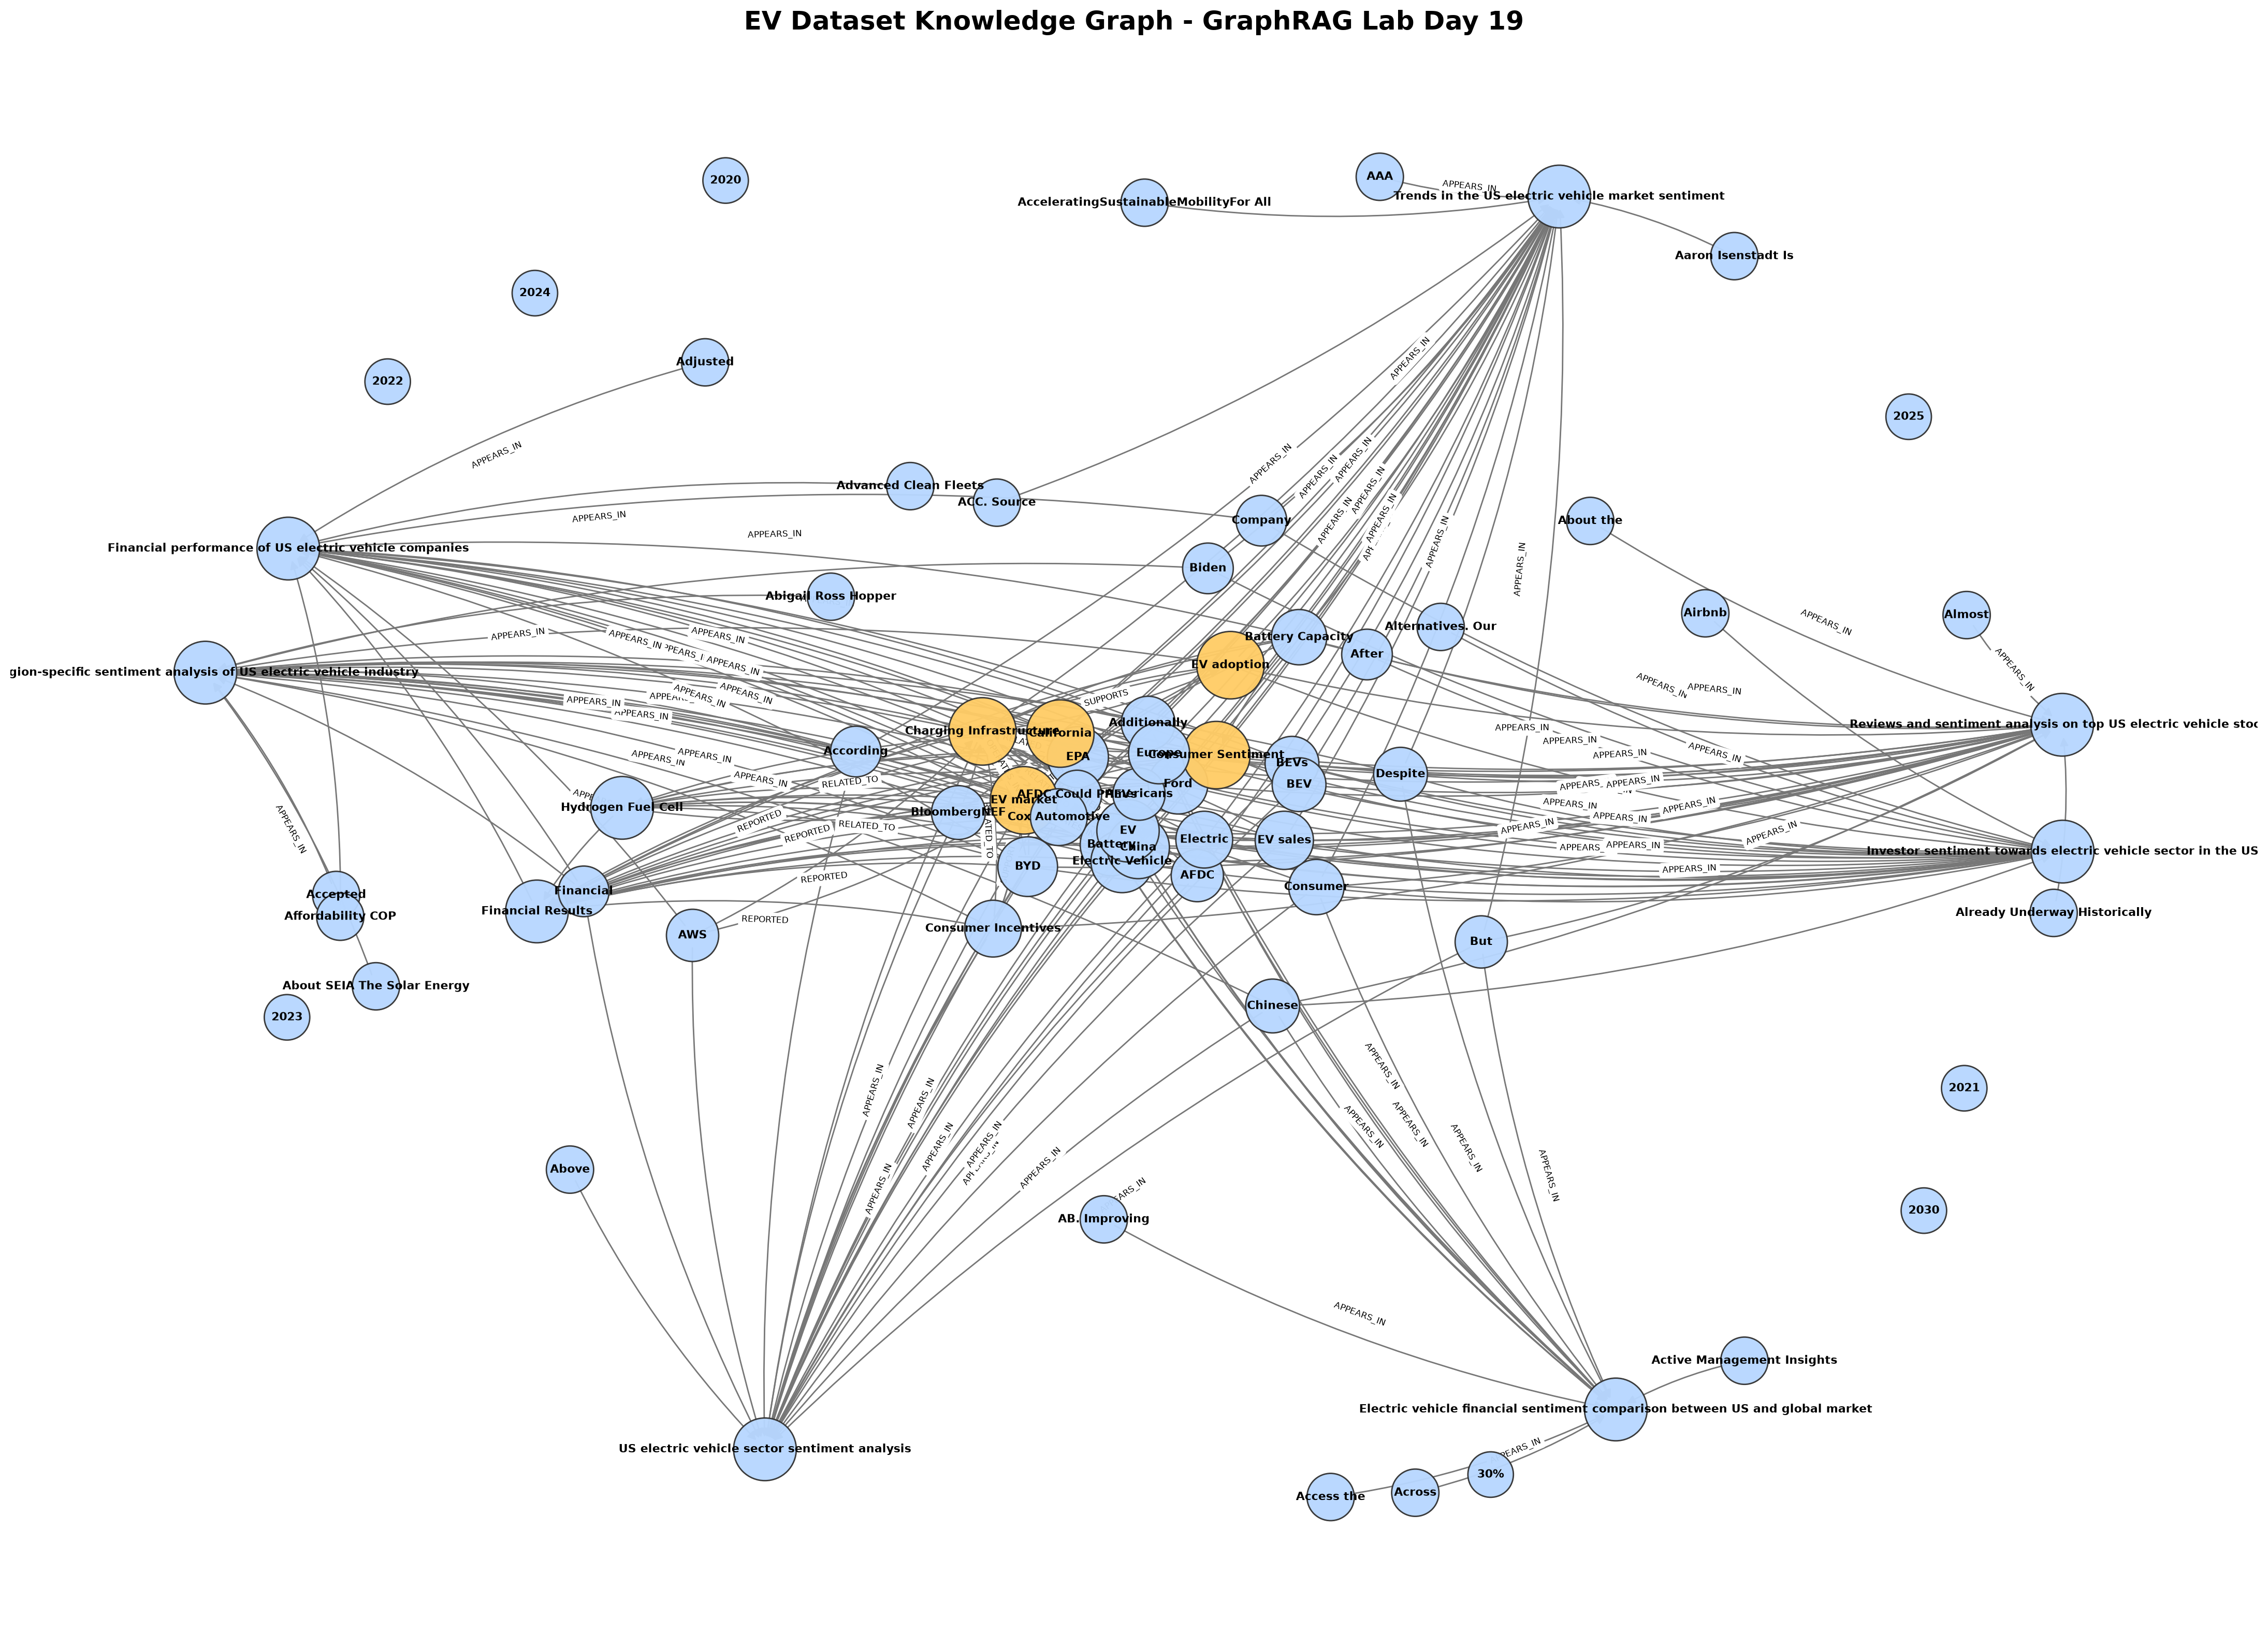

In [4]:
from IPython.display import Image, display
display(Image(filename='graphrag_knowledge_graph.png'))